In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device("cpu")

epochs = 10
batch_size = 1024
learning_rate = 1e-3

shift = 3
max_chars = 150
eval_samples = 1000

## Чтение и исследование данных

In [29]:
data = pd.read_parquet("English_Sentences_Clean.parquet")

data

,english_sentence
0,politicians do not have permission to do what ...
1,"I'd like to tell you about one such child,"
2,This percentage is even greater than the perce...
3,what we really mean is that they're bad at not...
4,.The ending portion of these Vedas is called U...
...,...
124307,Examples of art deco construction can be found...
124308,and put it in our cheeks.
124309,"As for the other derivatives of sulphur , the ..."
124310,its complicated functioning is defined thus in...


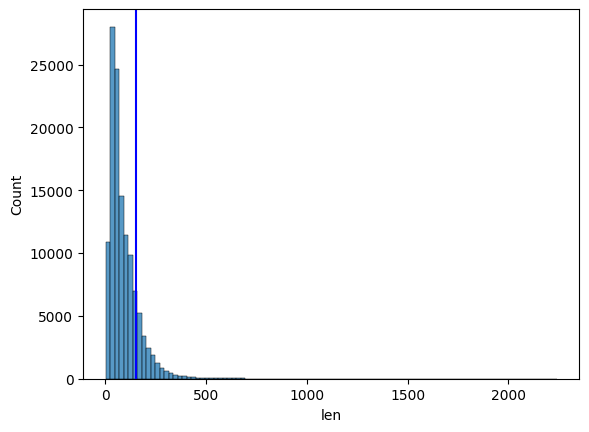

In [30]:
data["len"] = data["english_sentence"].astype(str).str.len()

sns.histplot(data["len"], bins=100)
plt.axvline(x=max_chars, color="blue")
plt.show()

In [31]:
data = data[data["len"] <= max_chars]

In [32]:
from collections import Counter


all_text = ''.join(data.fillna('').astype(str).to_numpy().ravel())
symbol_counts = Counter(all_text)

symbol_counts

Counter({' ': 1131632,
         'e': 632899,
         'a': 470068,
         't': 464755,
         'i': 393781,
         'o': 392879,
         'n': 378269,
         's': 341414,
         'r': 325917,
         'h': 275605,
         'l': 211078,
         'd': 202936,
         'c': 149476,
         'u': 147361,
         'm': 131723,
         'f': 113027,
         'g': 101300,
         'p': 101188,
         'y': 94045,
         'w': 92526,
         'b': 74409,
         '.': 73922,
         'v': 55322,
         ',': 53435,
         '1': 52453,
         'k': 38779,
         '3': 30783,
         '2': 30658,
         '4': 29891,
         '5': 25938,
         '0': 25388,
         'I': 24742,
         'T': 23357,
         '6': 22830,
         '9': 21748,
         '7': 20184,
         '8': 19731,
         'A': 19110,
         '-': 17008,
         'S': 16372,
         "'": 15945,
         'B': 13397,
         'M': 10215,
         'R': 9926,
         'H': 9790,
         'C': 9565,
         'j': 9091

## Создание датасета (токенизация данных)

In [33]:
from dataHandling import CaesarCipherHandler, MyTokenizer, get_loaders

alphabet = list(symbol_counts.keys())

handler = CaesarCipherHandler(alphabet, shift)
tokenizer = MyTokenizer(alphabet)

train_loader, test_loader = get_loaders(data["english_sentence"], handler, tokenizer, batch_size=batch_size)

![](image.png)

## Создание сети на GRU и тренировка

In [34]:
from gru import GRU

gru = GRU(input_size=len(tokenizer), hidden_size=128, output_size=len(tokenizer))

gru.to(device)

gru_optimizer = optim.Adam(gru.parameters(), lr=learning_rate)
gru_criterion = nn.CrossEntropyLoss()

In [35]:
from trainer import Trainer

gru_trainer = Trainer(gru, gru_criterion, gru_optimizer, device, epoch_amount=epochs)

In [36]:
# gru_trainer.fit(train_loader)

In [37]:
# plt.loglog(gru_trainer.train_loss, label="train")
# plt.legend()
# plt.show()

In [38]:
# gru_trainer.save("gru.pth")

## Создание сети на LSTM и тренировка

In [39]:
from lstm import LSTM

lstm = LSTM(input_size=len(tokenizer), hidden_size=128, output_size=len(tokenizer))

lstm.to(device)

lstm_optimizer = optim.Adam(lstm.parameters(), lr=learning_rate)
lstm_criterion = nn.CrossEntropyLoss()

In [40]:
from trainer import Trainer

lstm_trainer = Trainer(lstm, lstm_criterion, lstm_optimizer, device, epoch_amount=epochs)

In [ ]:
# lstm_trainer.fit(train_loader)

Epoch 1/10 train:   0%|          | 0/82 [00:00<?, ?it/s]

Эпоха 1: Loss_train: 3.3198487060826, 0:00:13.182084 сек


Epoch 2/10 train:   0%|          | 0/82 [00:00<?, ?it/s]

Эпоха 2: Loss_train: 2.5303669528263373, 0:00:13.335991 сек


Epoch 3/10 train:   0%|          | 0/82 [00:00<?, ?it/s]

...

Эпоха 8: Loss_train: 0.0442985178130429, 0:00:13.308106 сек


Epoch 9/10 train:   0%|          | 0/82 [00:00<?, ?it/s]

Эпоха 9: Loss_train: 0.031473952504556355, 0:00:13.375840 сек


Epoch 10/10 train:   0%|          | 0/82 [00:00<?, ?it/s]

Эпоха 10: Loss_train: 0.02369217645013478, 0:00:13.439731 сек


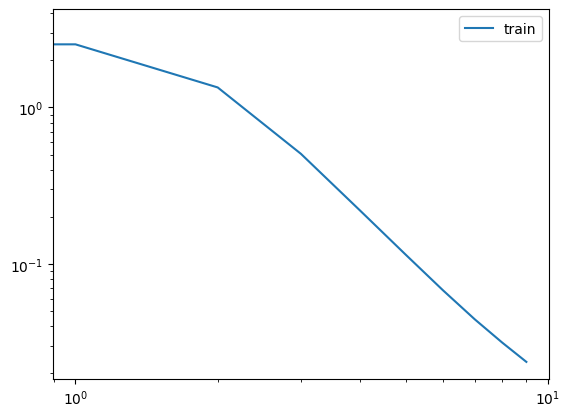

In [ ]:
# plt.loglog(lstm_trainer.train_loss, label="train")
# plt.legend()
# plt.show()

In [ ]:
# lstm_trainer.save("lstm.pth")

## Оценка результатов

In [45]:
gru_trainer.load("gru.pth")

In [46]:
preds = gru_trainer.predict(test_loader)

Predicting:   0%|          | 0/21 [00:00<?, ?it/s]

In [47]:
preds = preds.softmax(dim=2)
preds = preds.argmax(dim=2)
preds = [tokenizer.detokenize(pred) for pred in preds]
preds = [handler.decipher(pred) for pred in preds]
targets = test_loader.dataset.data

gru_preds = pd.DataFrame({"pred": preds, "target": targets})
gru_preds.head()

,pred,target
106931,One thousand prisoners who sat in meditation. ...,One thousand prisoners who sat in meditation.
53217,"But if you look at the spectrum, ...","But if you look at the spectrum,"
55933,And this is very difficult to do ...,And this is very difficult to do
85174,"especially adolescents, ...","especially adolescents,"
93264,Village Panchayats could also determine suits ...,Village Panchayats could also determine suits ...


In [48]:
from metrics import Metrics

metrics = Metrics()
samples = gru_preds.sample(eval_samples)
metrics.calculate_metrics(samples["pred"], samples["target"])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calculating metrics:   0%|          | 0/1000 [00:00<?, ?it/s]

/Users/andrey/Ground/25AIMEPhI/.venv/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/Users/andrey/Ground/25AIMEPhI/.venv/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/Users/andrey/Ground/25AIMEPhI/.venv/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.


,value,mean
levenshtein_distance,86395.000000,86.395000
levenshtein_similarity,558.954450,0.558954
jaccard_similarity,991.049183,0.991049
tfidf_similarity,993.016097,0.993016
sequence_matcher,558.954450,0.558954
bleu_score,918.839035,0.918839
sentence_transformer,997.033745,0.997034


In [49]:
lstm_trainer.load("lstm.pth")

In [50]:
preds = lstm_trainer.predict(test_loader)

Predicting:   0%|          | 0/21 [00:00<?, ?it/s]

In [51]:
preds = preds.softmax(dim=2)
preds = preds.argmax(dim=2)
preds = [tokenizer.detokenize(pred) for pred in preds]
preds = [handler.decipher(pred) for pred in preds]
targets = test_loader.dataset.data

lstm_preds = pd.DataFrame({"pred": preds, "target": targets})
lstm_preds.head()

,pred,target
106931,One thousand prisoners who sat in meditation. ...,One thousand prisoners who sat in meditation.
53217,"But if you look at the spectrum, ...","But if you look at the spectrum,"
55933,And this is very difficult to do ...,And this is very difficult to do
85174,"especially adolescents, ...","especially adolescents,"
93264,Village Panchayats could also determine suits ...,Village Panchayats could also determine suits ...


In [52]:
from metrics import Metrics

metrics = Metrics()
samples = lstm_preds.sample(eval_samples)
metrics.calculate_metrics(samples["pred"], samples["target"])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calculating metrics:   0%|          | 0/1000 [00:00<?, ?it/s]

/Users/andrey/Ground/25AIMEPhI/.venv/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/Users/andrey/Ground/25AIMEPhI/.venv/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/Users/andrey/Ground/25AIMEPhI/.venv/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.


,value,mean
levenshtein_distance,86534.000000,86.534000
levenshtein_similarity,555.543798,0.555544
jaccard_similarity,987.143452,0.987143
tfidf_similarity,989.019075,0.989019
sequence_matcher,555.543798,0.555544
bleu_score,911.825713,0.911826
sentence_transformer,996.279082,0.996279
